In [1]:
import pandas as pd
from snowflake_info import df

pd.set_option('display.max_columns', 50)

df.describe()

df = df.drop(columns='DATE') #posting date is irrelevant on prediction
df['PRICE'] = df['PRICE'].astype(int)
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PRICE                 21613 non-null  int64  
 1   BEDROOMS              21613 non-null  int8   
 2   BATHROOMS             21613 non-null  int8   
 3   SQFT_LIVING           21613 non-null  int16  
 4   SQFT_LOT              21613 non-null  int32  
 5   FLOORS                21613 non-null  object 
 6   WATERFRONT            21613 non-null  int8   
 7   VIEW                  21613 non-null  int8   
 8   CONDITION             21613 non-null  int8   
 9   GRADE                 21613 non-null  int8   
 10  SQFT_ABOVE            21613 non-null  float64
 11  SQFT_BASEMENT         21613 non-null  int16  
 12  YEAR_BUILT            21613 non-null  int16  
 13  YEAR_RENOVATED        21613 non-null  int16  
 14  LAT                   21613 non-null  float64
 15  LONG               

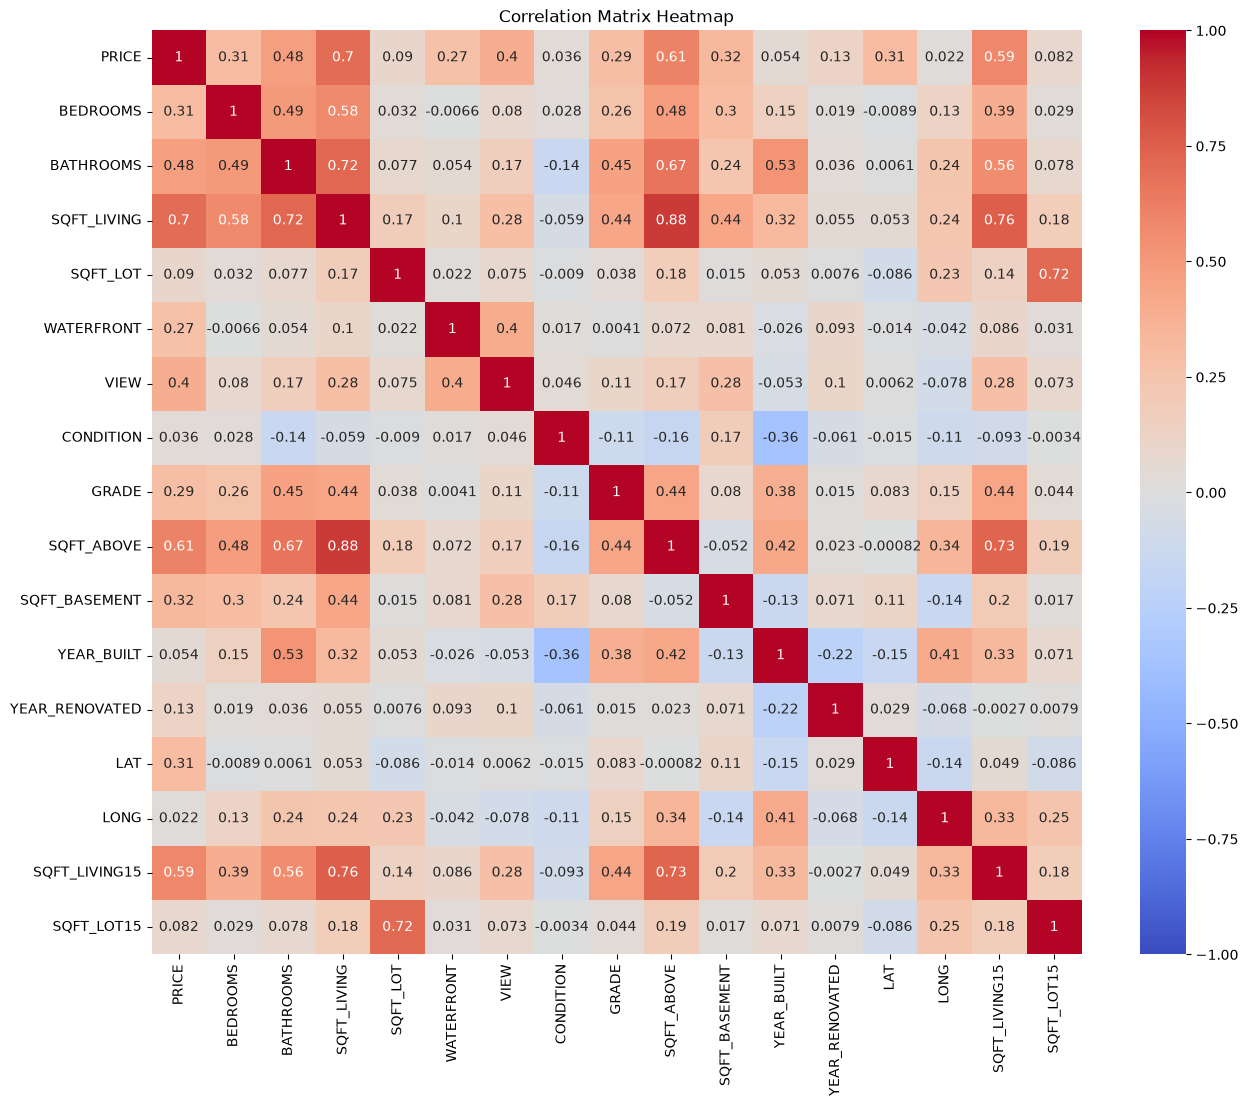

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = df.drop(columns=['EFFECTIVE_AGE'])

# 2. Calculate the correlation matrix (only works on numeric columns)
corr_matrix = df.corr(numeric_only=True)

# 3. Create the Seaborn heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()



In [4]:
df.corr()['PRICE']

PRICE             1.000000
BEDROOMS          0.308350
BATHROOMS         0.475331
SQFT_LIVING       0.702035
SQFT_LOT          0.089661
FLOORS            0.258001
WATERFRONT        0.266369
VIEW              0.397293
CONDITION         0.036362
GRADE             0.292309
SQFT_ABOVE        0.605567
SQFT_BASEMENT     0.323816
YEAR_BUILT        0.054012
YEAR_RENOVATED    0.126434
LAT               0.307003
LONG              0.021626
SQFT_LIVING15     0.585379
SQFT_LOT15        0.082447
ZIPCODE           0.638270
Name: PRICE, dtype: float64

In [5]:
import numpy as np

# Downtown Seattle Coordinates
seattle_lat = 47.6062
seattle_long = -122.3321

def haversine_distance(lat1, lon1, lat2, lon2):
    # Radius of Earth in kilometers
    R = 6371.0 
    
    # Convert coordinates to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# Apply the function to create a new feature column
df['distance_to_seattle_km'] = haversine_distance(
    df['LAT'], df['LONG'], 
    seattle_lat, seattle_long
)

df = df.drop(columns=['LAT','LONG'])

df.corr()['PRICE']

PRICE                     1.000000
BEDROOMS                  0.308350
BATHROOMS                 0.475331
SQFT_LIVING               0.702035
SQFT_LOT                  0.089661
FLOORS                    0.258001
WATERFRONT                0.266369
VIEW                      0.397293
CONDITION                 0.036362
GRADE                     0.292309
SQFT_ABOVE                0.605567
SQFT_BASEMENT             0.323816
YEAR_BUILT                0.054012
YEAR_RENOVATED            0.126434
SQFT_LIVING15             0.585379
SQFT_LOT15                0.082447
ZIPCODE                   0.638270
distance_to_seattle_km   -0.287048
Name: PRICE, dtype: float64

_distance_to_seattle_km is negative, it means: As the distance to Seattle INCREASES, the price DECREASES. This completely aligns with the idea that being closer to the city center comes with a premium price tag, and moving further away gets you a cheaper house._

_SQFT_LIVING (0.702035): It confirms that the physical size of the living space is the absolute biggest driver of price._

_ZIPCODE (0.638270): Location is big factor to the price_

In [6]:
df = df.drop(columns=['YEAR_BUILT','YEAR_RENOVATED'])

_A score of 0.054 in year_built is extremely close to zero._
_This proves that the age of the house does not strictly dictate the price. A house built in 1950 and a house built in 2010 could be the exact same price._

In [8]:
df = df.drop(columns='CONDITION')

_CONDITION having lower correlation that means in this dataset its not the factor of the price_

In [7]:
df = df.drop(columns=['SQFT_LOT15','SQFT_LOT'])

_SQFT LOTS having lower correlation proves that Lot size doesn't drive price in King County. The most expensive homes are usually packed onto tiny lots near the city, while massive lots are located in the cheaper, rural suburbs. Ultimately, buyers in this market are paying a premium for indoor living space, not a big yard._

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns='PRICE')
y = df['PRICE']

x_test, x_train, y_test , y_train = train_test_split(x,y, test_size=0.2, random_state=42)

scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.fit_transform(x_test)

lr_model = LinearRegression()
rf_model = RandomForestRegressor(max_depth=6, random_state=42)
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)

lr_model.fit(x_train_scaled, y_train)
rf_model.fit(x_train_scaled, y_train)
dt_model.fit(x_train_scaled, y_train)

models = {
    "linear": lr_model,
    'forest': rf_model,
    'tree': dt_model
}

results = []

for name,model in models.items():
 
    y_pred = model.predict(x_test_scaled)

    r2 = r2_score(y_pred, y_test)
    rmse = root_mean_squared_error(y_pred, y_test)
    
    results.append({
        'Model': name,
        'R2 Score': r2,
        'RMSE': rmse
    })

result_df = pd.DataFrame(results)

print(result_df)


    Model  R2 Score           RMSE
0  linear  0.730072  170823.995488
1  forest  0.764800  152923.991342
2    tree  0.675130  197519.982257
